# Indirect methods I (minimum propellant, fixed time)

This notebook presents a fixed-time, minimum-propellant low-thrust transfer solved with an indirect method.

We derive a TPBVP (Two-Point Boundary Value Problem) from Pontryagin's Minimum Principle (PMP), solve it with single shooting, and then introduce continuation strategies for harder cases.

The goal is not only to solve one transfer, but to provide a reusable workflow that can be adapted to other optimal-control problems by changing dynamics, boundary conditions, and optimality conditions.

Most symbolic and differentiation steps can be automated using `heyoka`, and many of the resulting building blocks are already exposed in `pykep` for production use.

A companion tutorial for the time-optimal variant is available here: [time-optimal case](./pontryagin_cartesian_time.ipynb).

## Reusable workflow (for other OCPs)
Use the same pattern when adapting this strategy to a different optimization problem:

1. Define dynamics, boundary conditions, and admissible controls.
2. Build the Hamiltonian and derive the minimizing control law (and switching function).
3. Substitute optimal controls to obtain a closed state-costate TPBVP.
4. Solve with single shooting plus multi-start.
5. Add continuation on a homotopy parameter when direct convergence fails.
6. Validate feasibility, control bounds, and Hamiltonian consistency before interpreting optimality.

In [33]:
import pykep as pk
import numpy as np
import heyoka as hy
import pygmo as pg
import pygmo_plugins_nonfree as ppnf
import time

from matplotlib import pyplot as plt

## Manual construction of the TPBVP
We consider the dynamics

$$
\left\{
\begin{array}{l}
\dot{\mathbf r} = \mathbf v \\
\dot{\mathbf v} = -\frac{\mu}{r^3}\mathbf r + c_1\frac{u}{m}\hat{\mathbf i} \\
\dot{m} = -\frac{c_1}{c_2}u
\end{array}
\right.,
$$

with control constraints $0 \le u \le 1$ and $\|\hat{\mathbf i}\| = 1$. Here $c_1 = T_{\max}$ and $c_2 = I_{sp}g_0$.

To apply PMP, we introduce one costate per state variable. Using `heyoka` as a symbolic manipulator, we define symbols for all time-dependent quantities:

In [34]:
# State variables
x, y, z, vx, vy, vz, m = hy.make_vars("x", "y", "z", "vx", "vy", "vz", "m")
# Costate variables
lx, ly, lz, lvx, lvy, lvz, lm = hy.make_vars(
    "lx", "ly", "lz", "lvx", "lvy", "lvz", "lm",
)
# Control variables: throttle and thrust direction
u, ix, iy, iz = hy.make_vars("u", "ix", "iy", "iz")

To keep the derivation readable, we define compact expressions and group state/costate components into 3D vectors.

In [35]:
# Reusable scalar expressions
r3 = (x**2 + y**2 + z**2) ** (1.5)
lv_norm = hy.sqrt(lvx**2 + lvy**2 + lvz**2)

# Vectorized groupings for compact Hamiltonian expressions
lr = np.array([lx, ly, lz])
lv = np.array([lvx, lvy, lvz])
r = np.array([x, y, z])
v = np.array([vx, vy, vz])
i_vers = np.array([ix, iy, iz])

The dynamics can then be written as:

In [36]:
# Dynamics
fr = v
fv = hy.par[1] * u / m * i_vers - (hy.par[0] / r3) * r
fm = -hy.par[1] / hy.par[2] * u

We introduce the regularized Hamiltonian (with $\mathbf x$ the full state, $\boldsymbol\lambda$ the full costate, and $\mathbf u$ the control tuple):

$$
\mathcal H(\mathbf x, \boldsymbol\lambda, \mathbf u) = \boldsymbol\lambda_r \cdot \mathbf f_r + \boldsymbol\lambda_v \cdot \mathbf f_v + \lambda_m f_m + \lambda_0\frac{c_1}{c_2}\left(u - \epsilon\log\left(u(1-u)\right)\right).
$$

The logarithmic barrier regularizes the bang-bang throttle law, enforces interior controls during continuation, and recovers near bang-bang behavior as $\epsilon \to 0^+$.

In [37]:
# Regularized Hamiltonian
H_full = lr @ fr + lv @ fv + lm * fm + hy.par[4] * hy.par[1] / hy.par[2] * (u - hy.par[3] * hy.log(u * (1 - u)))
# Switching function rho from first-order optimality conditions
rho = 1. - hy.par[2] * lv_norm / m / hy.par[4] - lm / hy.par[4]


In the code, constants are passed as `heyoka` parameters in the order $[\mu, c_1, c_2, \epsilon, \lambda_0]$, with $c_1 = T_{\max}$ and $c_2 = I_{sp}g_0$. Consequently, $\frac{c_1}{c_2} = \frac{T_{\max}}{I_{sp}g_0}$.

We write the resulting Hamiltonian system:

$$
\left\{
\begin{array}{l}
\dot{\mathbf x} = \frac{\partial \mathcal H}{\partial \mathbf \lambda} \\
\dot{\mathbf \lambda} = - \frac{\partial \mathcal H}{\partial \mathbf x} \\
\end{array}\right.
$$

In [38]:
# Augmented equations of motion
rhs = [
    hy.diff(H_full, var)
    for var in [lx, ly, lz, lvx, lvy, lvz, lm, x, y, z, vx, vy, vz, m]
]
for j in range(7, 14):
    rhs[j] = -rhs[j]

Pontryagin's minimum principle requires pointwise minimization of the Hamiltonian over the admissible control set

$$
\mathbf u^*(t) = \arg\min_{\mathbf u \in \mathcal U} \mathcal H(\mathbf x, \boldsymbol\lambda, \mathbf u),
$$

with $\quad\mathcal U = \{(u, \hat{\mathbf i})\,|\,0 \le u \le 1,\ \|\hat{\mathbf i}\|=1\}$.

For this problem, the minimizer is:

In [39]:
# PMP minimizer: thrust direction anti-parallel to lambda_v
# Smoothed throttle law from regularized Hamiltonian minimization
argmin_H_full = {
    ix: -lvx / lv_norm,
    iy: -lvy / lv_norm,
    iz: -lvz / lv_norm,
    u: 2
    * hy.par[3]
    / (rho + 2 * hy.par[3] + hy.sqrt(rho * rho + 4 * hy.par[3] * hy.par[3])),
}

Using these relations, controls become smooth functions of state and costate. Substituting them into the dynamics yields a closed Hamiltonian system in $(\mathbf x, \boldsymbol\lambda)$, which is the TPBVP solved by shooting.

In [40]:
rhs = hy.subs(rhs, argmin_H_full)

# We also build the Hamiltonian as a function of the state / co-state only
# (i.e. no longer of controls now solved thanks to the minimum principle)
H = hy.subs(H_full, argmin_H_full)

The next block instantiates the `heyoka` integrator and helper evaluators used for diagnostics (Hamiltonian, switching function, and control law).

In [41]:
# Compile Hamiltonian evaluator (pars = [mu, c1, c2, eps, lambda0])
H_func = hy.cfunc([H], [x, y, z, vx, vy, vz, m, lx, ly, lz, lvx, lvy, lvz, lm])
# Compile optimal throttle evaluator
u_func = hy.cfunc(
    [argmin_H_full[u]], [x, y, z, vx, vy, vz, m, lx, ly, lz, lvx, lvy, lvz, lm]
)
# Compile switching-function evaluator
rho_func = hy.cfunc([rho], [x, y, z, vx, vy, vz, m, lx, ly, lz, lvx, lvy, lvz, lm])
# Compile optimal thrust-direction evaluator
i_vers_func = hy.cfunc(
    [argmin_H_full[ix], argmin_H_full[iy], argmin_H_full[iz]], [lvx, lvy, lvz]
)
# Assemble Taylor adaptive integrator
full_state = [x, y, z, vx, vy, vz, m, lx, ly, lz, lvx, lvy, lvz, lm]
sys = [(var, dvar) for var, dvar in zip(full_state, rhs)]
ta = hy.taylor_adaptive(sys, state=[1.0] * 14)

## Constructing the TPBVP using pykep

For this specific formulation, `pykep` provides pre-assembled building blocks that reproduce the same mathematical objects derived manually above.

In practice, this is the recommended route: the manual derivation is useful to understand and debug the method, while `pykep` utilities are preferable for robust and repeatable workflows.

In [42]:
# Taylor integrator
ta = pk.ta.get_pc(1e-16, pk.optimality_type.MASS)
# Variational Taylor integrator for sensitivities
ta_var = pk.ta.get_pc_var(1e-16, pk.optimality_type.MASS)
# Hamiltonian evaluator
H_func = pk.ta.get_pc_H_cfunc(pk.optimality_type.MASS)
# Switching-function evaluator
SF_func = pk.ta.get_pc_SF_cfunc(pk.optimality_type.MASS)
# Optimal throttle magnitude evaluator
u_func = pk.ta.get_pc_u_cfunc(pk.optimality_type.MASS)
# Optimal thrust-direction evaluator
i_vers_func = pk.ta.get_pc_i_vers_cfunc(pk.optimality_type.MASS)
# Dynamics evaluator
dyn_func = pk.ta.get_pc_dyn_cfunc(pk.optimality_type.MASS)

## Solving in single shooting

The previous section was mainly pedagogical. From this point onward, we use dedicated `pykep` classes directly.

As a first test case, we solve a relatively easy transfer between two 1 AU-class heliocentric orbits. Because this case is well-conditioned, we can target a small regularization parameter from the start ($\epsilon \ll 1$), without continuation.

A harder case requiring continuation is addressed later.

In [43]:
# Test case 1: direct solve at small epsilon (no continuation)
posvel0 = [
    [34110913367.783306, -139910016918.87585, -14037825669.025244],
    [29090.9902134693, 10000.390168313803, 1003.3858682643288],
]
posvelf = [
    [-159018773159.22266, -18832495968.945133, 15781467087.350443],
    [2781.182556622003, -28898.40730995848, -483.4533989771214],
]
tof = 250
mu = pk.MU_SUN
# Small epsilon approximates bang-bang mass-optimal structure
eps = 1e-5

We instantiate the shooting method using the UDP provided by `pykep`:

In [44]:
udp = pk.trajopt.pontryagin_cartesian_mass(
    posvel0=posvel0,
    posvelf=posvelf,
    tof=tof,
    mu=mu,
    lambda0 = None,
    eps=eps,
    T_max=0.6,
    Isp=3000,
    m0=1500,
    L=pk.AU,
    MU=mu,
    MASS=1500,
    with_gradient=True,
    taylor_tolerance=1e-6,  # Looser tolerance is sufficient for this easy case and improves runtime
    taylor_tolerance_var=1e-4,
)
prob = pg.problem(udp)
prob.c_tol = 1e-6

The resulting nonlinear TPBVP can be attacked with different numerical tools: SQP/interior-point optimizers or direct root-finding methods on boundary residuals.

Here we use IPOPT (interior-point, via `pagmo`) and a MINPACK wrapper (via `scipy.optimize.root`). Both are open-source and widely available.

IPOPT is natively exposed in `pagmo`:

In [45]:
ip = pg.ipopt()
ip.set_numeric_option("tol", 1e-8)  # Relative convergence tolerance
ip.set_integer_option("max_iter", 50)  # Maximum iterations
ip.set_integer_option("print_level", 0)  # Suppress IPOPT console output
ip.set_string_option(
    "sb", "yes"
)
ip.set_string_option(
    "nlp_scaling_method", "none"
)  # Disable IPOPT automatic scaling
ip.set_string_option(
    "mu_strategy", "adaptive"
)  # Adaptive barrier update strategy
ipopt = pg.algorithm(ip)

MINPACK is available via scipy and is missing in the current pygmo version, but we can quickly provide a wrapper as a UDA:

In [46]:
class my_solver:
    def __init__(self, gradient):
        self.gradient = gradient
    def evolve(self, pop: pg.population):
        from scipy.optimize import root
        prob = pop.problem
        x0 = pop.champion_x
        n = pop.problem.get_nx()
        if self.gradient:
            res = root(lambda x: prob.fitness(x)[1:], x0, method="hybr", tol=1e-8, options = {"factor": 1., "diag": [1]*8}, jac=lambda x: prob.gradient(x).reshape(n,n))  # factor=1.0 is critical for robustness
        else:
            res = root(lambda x: prob.fitness(x)[1:], x0, method="hybr", tol=1e-8, options = {"factor": 1., "diag": [1]*8})  # factor=1.0 is critical for robustness
        pop.set_x(0, res["x"])
        return pop
    def get_name(self):
        return "Minpack hybrd routine"

minpack = pg.algorithm(my_solver(False))
minpack_g = pg.algorithm(my_solver(True))

We use a multi-start strategy, which is generally good practice in indirect optimization due to sensitivity to initialization. In this easy case, convergence is often immediate, but we still report robustness statistics.

In [47]:
def multistart(algo, n_trials=10):
    masses = []
    xs = []
    total_time = 0.0
    success=0

    for i in range(n_trials):
        pop = pg.population(udp,1)
        time_start = time.time()
        pop = algo.evolve(pop)
        time_end = time.time()
        total_time += time_end - time_start
        if prob.feasibility_f(pop.champion_f):
            print(".", end="")
            udp.fitness(pop.champion_x)
            xs.append(pop.champion_x)
            masses.append(udp.ta.state[6])
            success+=1
        else:
            print("x", end="")
    print(f"\nFinal mass is: {masses[0]*udp.MASS}")
    print(f"Hamiltonian at the final point is: {H_func(udp.ta.state, pars=udp.ta.pars)} \n")
    print(f"Total time to success: {total_time:.3f} seconds")
    print(f"Number of successes: {success} over {n_trials} trials ({success/n_trials*100:.1f} %)")
    return pop

In [48]:
pop = multistart(ipopt, 40)

...x..x..x.......x...x...xx.............
Final mass is: 1259.9009185958457
Hamiltonian at the final point is: [-0.05597389] 

Total time to success: 6.927 seconds
Number of successes: 33 over 40 trials (82.5 %)


In [50]:
pop = multistart(minpack_g, 40)

x..xxx...xxx.xx.......xx.xx..xx.xx.x.x..
Final mass is: 1259.9009186158119
Hamiltonian at the final point is: [-0.05597388] 

Total time to success: 0.574 seconds
Number of successes: 21 over 40 trials (52.5 %)


We now inspect the trajectory geometry obtained by the solver.

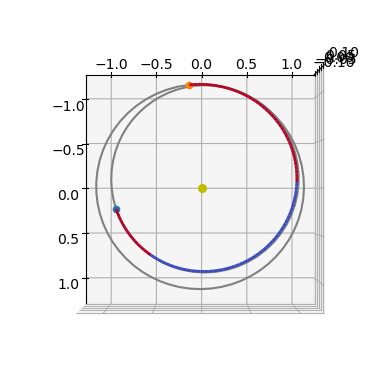

In [51]:
ax3D = udp.plot(pop.champion_x)
ax3D.view_init(90, 0)

In these plots, thrust arcs are shown in red and coast (ballistic) arcs in blue.

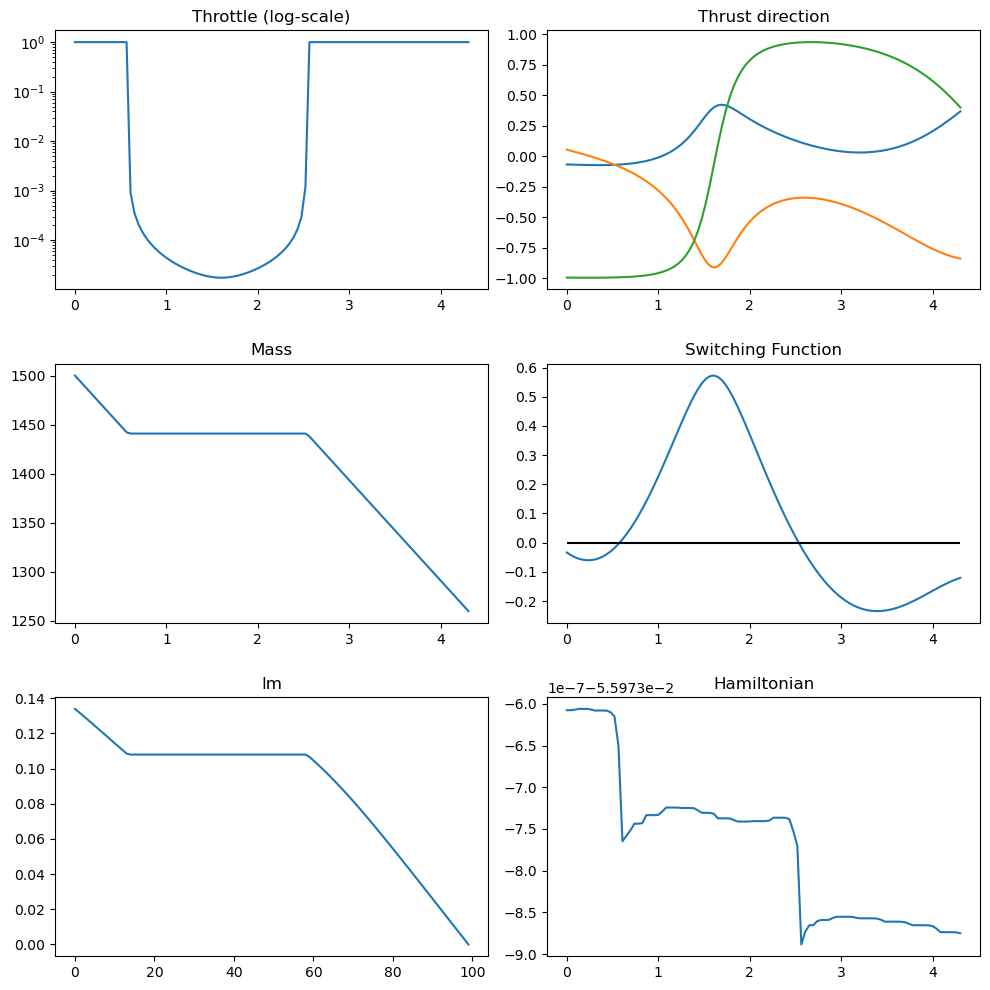

In [52]:
udp.plot_misc(pop.champion_x);

## Homotopy

The previous case is comparatively easy for single shooting. In many practical transfers (especially with multiple revolutions or complex switching structures), direct convergence at small $\epsilon$ is unreliable.

Continuation (homotopy) helps by solving a sequence of nearby problems and using each solution to warm-start the next one.

As a second test case, we use a harder Earth-Mars-like transfer for which direct solution at mass-optimal regularization (e.g., $\epsilon = 10^{-4}$) typically fails.

In [53]:
# Testcase 2 (less easy, homotopy needed) [Earth-Mars]
posvel0 = [
    [-125036811000.422, -83670919168.87277, 2610252.8064399767],
    [16081.829029183446, -24868.923007449284, 0.7758272135425942],
]
posvelf = [
    [-169327023332.1986, -161931354587.78766, 763967345.9733696],
    [17656.297796509956, -15438.116653052988, -756.9165272457421],
]
tof = 550. #days
mu = pk.MU_SUN
eps = 1e-1

## Exponential homotopy on $\epsilon$
We decrease $\epsilon$ geometrically and use the converged decision vector at step $k$ as the predictor (initial guess) for step $k+1$.
If convergence fails, we backtrack by increasing $\epsilon$ and continue from the last successful point.

In [54]:
# We instantiate a new optimzation roblem (a pygmo UDP) with the new parameters:
udp = pk.trajopt.pontryagin_cartesian_mass(
    posvel0=posvel0,
    posvelf=posvelf,
    tof=tof,
    mu=mu,
    lambda0 = None,
    eps=eps,
    T_max=0.6,
    Isp=3000,
    m0=1500,
    L=pk.AU,
    MU=mu,
    MASS=1500,
    with_gradient=True,
    taylor_tolerance=1e-6,  # low tolerances for this simple problem enhance speed greatly
    taylor_tolerance_var=1e-4,
)
prob = pg.problem(udp)
prob.c_tol = 1e-6

The following code block implements an exponential homotopy over $\epsilon$.

In [55]:
# We can select the algorithm here:
#algo = ipopt
algo = minpack_g

In [56]:
import time
from copy import deepcopy
from IPython.display import clear_output

# No initial guess
first = True
epsilon = 1e-1
decrease_factor = 0.85

# Solve
while True:
    # Set the current epsilon in the udp and construct a problem 
    # (a copy here will be made, so that the udp inside the prob object
    # is a different udp)
    udp.eps = epsilon
    prob = pg.problem(udp)
    prob.c_tol = 1e-6

    # First time looks for a solution, then it continues it
    if first:
        # Creates a random ic population
        pop = pg.population(prob, 1)
        # Starts the time to profile the homotopy time only 
        # (i.e. we exclude the effort to find the first valid traj)
        tstart_tot = time.time()
    else:
        # Use predicted new chromosome
        pop = pg.population(prob)
        pop.push_back(predicted_chromosome)

    # Evolve
    tstart = time.time()
    pop = algo.evolve(pop)
    tend = time.time()

    # Compute constraint violation norm
    err = np.linalg.norm(pop.champion_f[1:])

    # If we find a feasible solution (either the first or a continued one, we log and start the predictor)
    if prob.feasibility_f(pop.champion_f):
        first = False
        clear_output(wait=True)
        print(
            f". Success!! | Error: {err:.2e} | CPU time: {tend-tstart:.2e} | Epsilon = {epsilon:.4e}"
        )

        # Save decision vector for current epsilon (which will be used as an initial guess in the next iteration)
        predicted_chromosome = deepcopy(pop.champion_x)
        best_epsilon = epsilon

        # Save current epsilon (needed if iteration fails)
        epsilon_previous = epsilon

        # Decrease epsilon
        epsilon = epsilon * decrease_factor

        # Stopping condition (desired epsilon reached)
        if epsilon < 1e-4:
            print(
                f"Desired epsilon reached ! | Error: {err:.2e} | CPU time: {tend-tstart:.2e} | Epsilon = {epsilon:.4e}"
            )
            break

    else:
        clear_output(wait=True)
        print(
            f"x | Error: {err:.2e} | CPU time: {tend-tstart:.2e} | Epsilon = {epsilon:.4e}"
        )

        # If first iteration fails, try again with different initial guess
        if first:
            pass

        # Epsilon is too small, we need to increase it (halfway between previous and current)
        else:
            epsilon_previous_new = epsilon
            epsilon = epsilon + abs(epsilon_previous - epsilon) / 2
            epsilon_previous = epsilon_previous_new
tend_tot = time.time()
print(f"Total CPU time: {tend_tot - tstart_tot:.2e}")

. Success!! | Error: 4.18e-10 | CPU time: 1.26e-02 | Epsilon = 1.0854e-04
Desired epsilon reached ! | Error: 4.18e-10 | CPU time: 1.26e-02 | Epsilon = 9.2260e-05
Total CPU time: 1.01e+00


A larger decrease factor would reduce total runtime, but only if the predictor remains accurate enough for convergence.

With a simple previous-solution predictor, aggressive steps tend to fail, forcing backtracking. This motivates a better predictor based on tangent continuation.

Let us plot the converged solution.

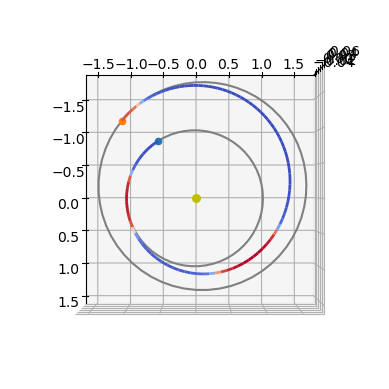

In [57]:
ax3D = udp.plot(pop.champion_x)
ax3D.view_init(90, 0)

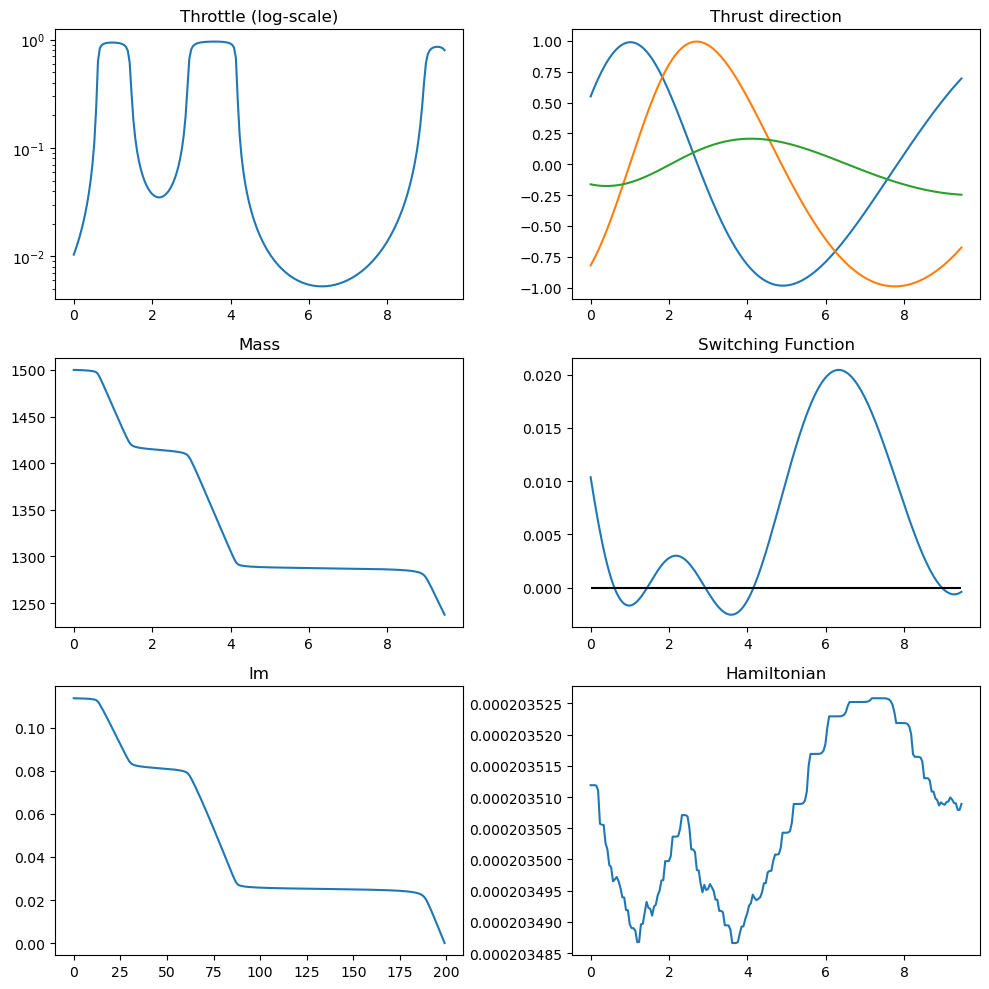

In [58]:
udp.plot_misc(pop.champion_x, N=200);

## Continuation along the tangent direction

Here we still decrease $\epsilon$ geometrically, but we compute a first-order predictor from the tangent to the solution manifold.

Let the TPBVP terminal constraints be

$$
\mathbf c(\boldsymbol\lambda, \epsilon) = \mathbf 0,
$$

where $\boldsymbol\lambda = [\lambda_x, \lambda_y, \lambda_z, \lambda_{vx}, \lambda_{vy}, \lambda_{vz}, \lambda_m, \lambda_0]^T$.
For a small parameter change $(\delta\boldsymbol\lambda, \delta\epsilon)$:

$$
\mathbf c(\boldsymbol\lambda + \delta\boldsymbol\lambda, \epsilon + \delta\epsilon) = \mathbf 0.
$$

Linearizing gives

$$
\frac{\partial \mathbf c}{\partial \boldsymbol\lambda}\,\delta\boldsymbol\lambda + \frac{\partial \mathbf c}{\partial \epsilon}\,\delta\epsilon = \mathbf 0,
$$

hence

$$
\delta\boldsymbol\lambda = -\mathbf A^{-1}\mathbf B\,\delta\epsilon,
$$

with $\mathbf A = \frac{\partial \mathbf c}{\partial \boldsymbol\lambda}$ and $\mathbf B = \frac{\partial \mathbf c}{\partial \epsilon}$.

Most entries in $\mathbf A$ and $\mathbf B$ are obtained directly from a variational Taylor integrator. The normalization constraint involving $\lambda_0$ is handled analytically.

We now build a first-order variational system with variables $[\lambda_x, \lambda_y, \lambda_z, \lambda_{vx}, \lambda_{vy}, \lambda_{vz}, \lambda_m, \lambda_0, \epsilon]$.

In [59]:
sys = pk.ta.pc_dyn(pk.optimality_type.MASS)
lx, ly, lz, lvx, lvy, lvz, lm = hy.make_vars("lx", "ly", "lz", "lvx", "lvy", "lvz", "lm")
var_sys = hy.var_ode_sys(sys, [lx, ly, lz, lvx, lvy, lvz, lm, hy.par[4], hy.par[3]])
ta_var = hy.taylor_adaptive(var_sys, compact_mode = True)
ic_var = deepcopy(ta_var.state[14:])

The helper below initializes the variational integrator state from a given decision vector.

In [60]:
def set_ta_var_state(udp, x, ta_var, ic_var):
    # Preparing the numerical integration parameters
    ta_var.pars[0] = udp.mu
    ta_var.pars[1] = udp.c1
    ta_var.pars[2] = udp.c2
    ta_var.pars[3] = udp.eps
    ta_var.pars[4] = x[7]
    ta_var.time = 0.0

    # And initial conditions
    ta_var.state[:3] = udp.posvel0[0]
    ta_var.state[3:6] = udp.posvel0[1]
    ta_var.state[6] = udp.m0
    ta_var.state[7:14] = x[:7]
    ta_var.state[14:] = ic_var

In [61]:
import time
from copy import deepcopy
from IPython.display import clear_output

# No initial guess
first = True
epsilon = 1e-1
decrease_factor = 0.75

# Solve
while True:
    # Set the current epsilon in the udp (for later plotting)
    udp.eps = epsilon
    prob = pg.problem(udp)
    prob.c_tol = 1e-4

    # Random initial guess
    if first:
        # Creates a random ic population
        pop = pg.population(prob, 1)
        tstart_tot = time.time()
    # Use best chromosome from previous iteration
    else:
        pop = pg.population(prob)
        pop.push_back(predicted_chromosome)

    # Evolve
    tstart = time.time()
    pop = algo.evolve(pop)
    tend = time.time()

    # Compute error of fitness vector
    err = np.linalg.norm(pop.champion_f[1:])

    if prob.feasibility_f(pop.champion_f):
        clear_output(wait=True)
        print(
            f". Success!! | Error: {err:.2e} | CPU time: {tend-tstart:.2e} | Epsilon = {epsilon:.4e}"
        )
        
        # Stopping condition (desired epsilon reached)
        if epsilon < 1e-4:
            print(
                f"Desired epsilon reached ! | Error: {err:.2e} | CPU time: {tend-tstart:.2e} | Epsilon = {epsilon:.4e}"
            )
            predicted_chromosome = deepcopy(pop.champion_x)
            break

        # Save decision vector for current epsilon (which will be used as an initial guess in the next iteration)
        predicted_chromosome = deepcopy(pop.champion_x)
        first = False
        best_epsilon = epsilon
        
        # Compute tangent vector
        set_ta_var_state(udp, pop.champion_x, ta_var, ic_var)
        ta_var.propagate_until(udp.tof)

        # Find the tangent vector
        set_ta_var_state(udp, predicted_chromosome, ta_var, ic_var)
        ta_var.propagate_until(udp.tof);
        A = np.zeros((8,8))
        B = np.zeros((8,1))
        # Filling up the constraints on final state
        for i, component in enumerate([0,1,2,3,4,5,13]):
            slice = ta_var.get_vslice(order = 1, component = component)
            B[i,0] = ta_var.state[slice][-1]
            A[i, :] = ta_var.state[slice][:-1]
        # Filling up the constraints norm of lambda
        A[7,:] = 2*predicted_chromosome
        dx = np.ravel(- np.linalg.inv(A) @ B)

        # Save current epsilon (needed if next iteration fails)
        epsilon_previous = epsilon

        # Decrease epsilon
        f_decrease = decrease_factor
        predicted_chromosome = predicted_chromosome + dx * epsilon * (f_decrease-1)
        epsilon = epsilon * f_decrease

    else:
        clear_output(wait=True)
        print(
            f"x | Error: {err:.2e} | CPU time: {tend-tstart:.2e} | Epsilon = {epsilon:.4e}"
        )

        # If first iteration fails, try again with different initial guess
        if first:
            pass

        # Epsilon is too small, we need to increase it (halfway between previous and current)
        else:
            epsilon_previous_new = epsilon
            epsilon = epsilon + abs(epsilon_previous - epsilon) / 2
            epsilon_previous = epsilon_previous_new
tend_tot = time.time()
print(f"Total CPU time: {tend_tot - tstart_tot:.2e}")

. Success!! | Error: 3.74e-12 | CPU time: 1.23e-02 | Epsilon = 7.5254e-05
Desired epsilon reached ! | Error: 3.74e-12 | CPU time: 1.23e-02 | Epsilon = 7.5254e-05
Total CPU time: 1.16e+00


With tangent prediction, continuation is typically smoother and faster because each warm start better follows the local solution manifold.